<a href="https://colab.research.google.com/github/pughbrennan02-ai/Diamond-Assignment/blob/main/Homework_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.precision", 4)
diabetes = load_diabetes(as_frame=True)
X = diabetes.data
y = diabetes.target
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("Features:", list(diabetes.feature_names))

Feature matrix shape: (442, 10)
Target vector shape: (442,)
Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [2]:
diabetes_df = X.copy()
diabetes_df["DiseaseProgression"] = y
display(diabetes_df.head())
display(diabetes_df.describe().T)
display(diabetes_df.isna().sum().to_frame("Missing values"))

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,DiseaseProgression
0,0.0381,0.0507,0.0617,0.0219,-0.0442,-0.0348,-0.0434,-0.0026,0.0199,-0.0176,151.0
1,-0.0019,-0.0446,-0.0515,-0.0263,-0.0084,-0.0192,0.0744,-0.0395,-0.0683,-0.0922,75.0
2,0.0853,0.0507,0.0445,-0.0057,-0.0456,-0.0342,-0.0324,-0.0026,0.0029,-0.0259,141.0
3,-0.0891,-0.0446,-0.0116,-0.0367,0.0122,0.0250,-0.0360,0.0343,0.0227,-0.0094,206.0
4,0.0054,-0.0446,-0.0364,0.0219,0.0039,0.0156,0.0081,-0.0026,-0.0320,-0.0466,135.0


,count,mean,std,min,25%,50%,75%,max
age,442.0,-2.5118e-19,0.0476,-0.1072,-0.0373,0.0054,0.0381,0.1107
sex,442.0,1.2308e-17,0.0476,-0.0446,-0.0446,-0.0446,0.0507,0.0507
bmi,442.0,-2.2456e-16,0.0476,-0.0903,-0.0342,-0.0073,0.0312,0.1706
bp,442.0,-4.7976e-17,0.0476,-0.1124,-0.0367,-0.0057,0.0356,0.1320
s1,442.0,-1.3815e-17,0.0476,-0.1268,-0.0342,-0.0043,0.0284,0.1539
s2,442.0,3.9184e-17,0.0476,-0.1156,-0.0304,-0.0038,0.0298,0.1988
s3,442.0,-5.7772e-18,0.0476,-0.1023,-0.0351,-0.0066,0.0293,0.1812
s4,442.0,-9.0425e-18,0.0476,-0.0764,-0.0395,-0.0026,0.0343,0.1852
s5,442.0,9.2937e-17,0.0476,-0.1261,-0.0332,-0.0019,0.0324,0.1336
s6,442.0,1.1303e-17,0.0476,-0.1378,-0.0332,-0.0011,0.0279,0.1356


,Missing values
age,0
sex,0
bmi,0
bp,0
s1,0
s2,0
s3,0
s4,0
s5,0
s6,0


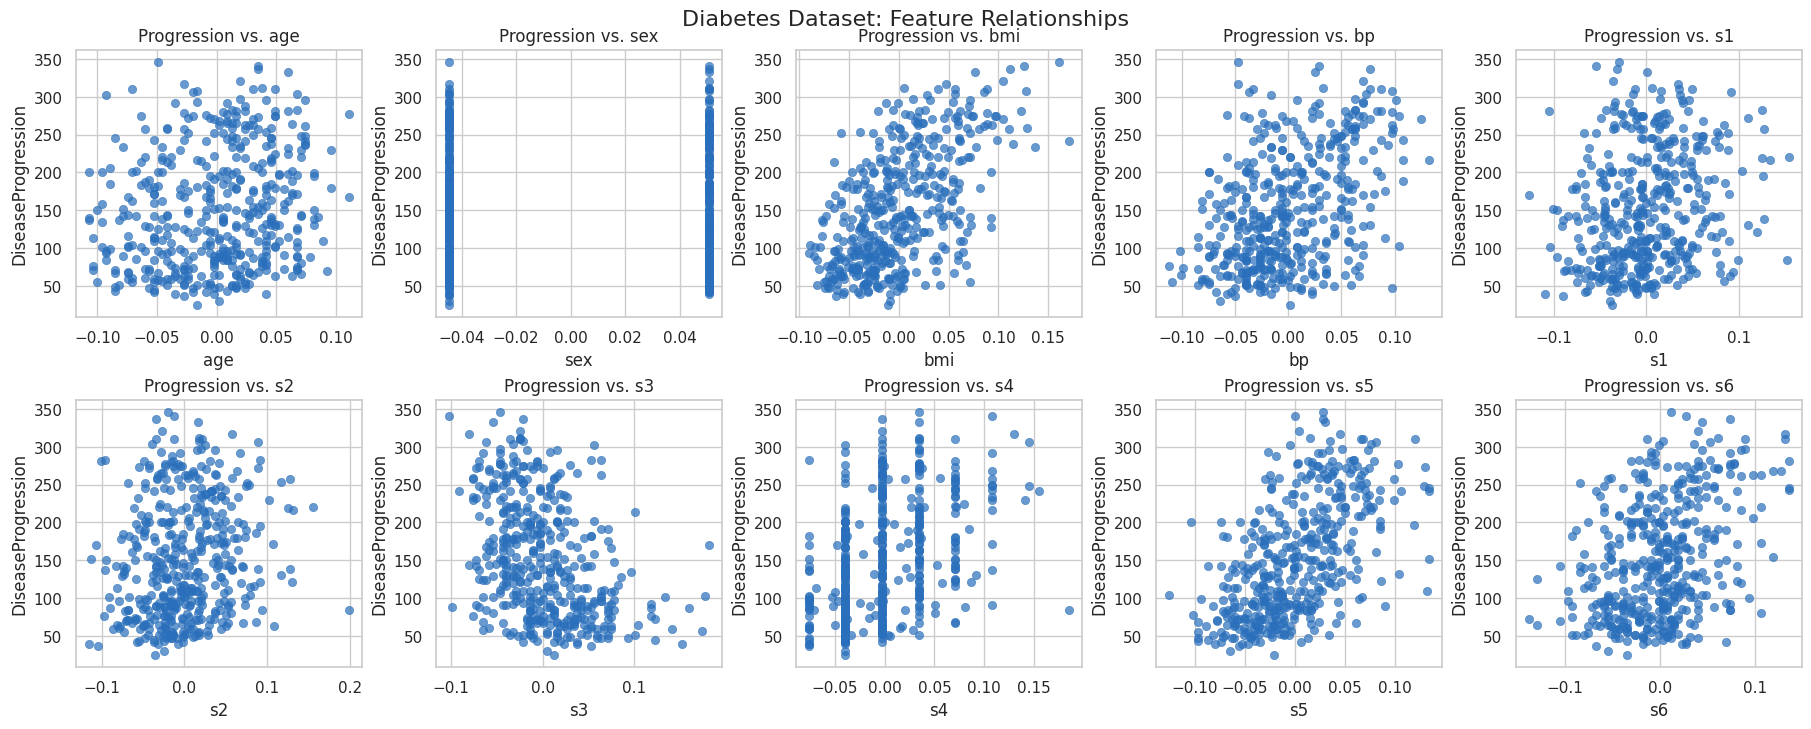

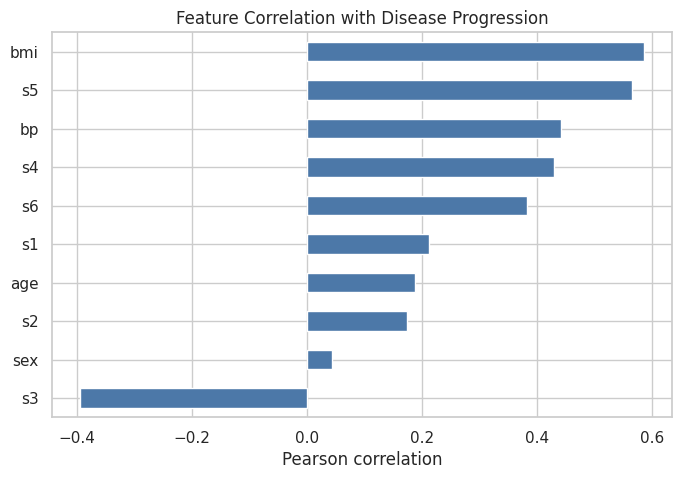

,Correlation with target
bmi,0.5865
s5,0.5659
bp,0.4415
s4,0.4305
s6,0.3825
s1,0.2120
age,0.1879
s2,0.1741
sex,0.0431
s3,-0.3948


In [3]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7), constrained_layout=True)
for ax, feature in zip(axes.flat, diabetes.feature_names):
    sns.scatterplot(data=diabetes_df, x=feature, y="DiseaseProgression", ax=ax, color="#2a6fbb", alpha=0.7, edgecolor=None)
    ax.set_title(f"Progression vs. {feature}")
fig.suptitle("Diabetes Dataset: Feature Relationships", fontsize=16, y=1.02)
plt.show()

correlations = diabetes_df.corr(numeric_only=True)["DiseaseProgression"].drop("DiseaseProgression")
correlations.sort_values().plot(kind="barh", figsize=(8, 5), color="#4c78a8")
plt.title("Feature Correlation with Disease Progression")
plt.xlabel("Pearson correlation")
plt.show()
display(correlations.sort_values(ascending=False).to_frame("Correlation with target"))

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=11)
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (331, 10)
Testing shape: (111, 10)


In [5]:
from sklearn.linear_model import LinearRegression
linear_regression = LinearRegression()
linear_regression.fit(X_train, y_train)
coefficients = pd.DataFrame({"Feature": diabetes.feature_names, "Coefficient": linear_regression.coef_})
coefficients["Absolute coefficient"] = coefficients["Coefficient"].abs()
coefficients = coefficients.sort_values("Absolute coefficient", ascending=False)
print(f"Intercept: {linear_regression.intercept_:.4f}")
display(coefficients)

Intercept: 152.2282


,Feature,Coefficient,Absolute coefficient
8,s5,622.3287,622.3287
2,bmi,523.0634,523.0634
4,s1,-336.1615,336.1615
3,bp,310.5135,310.5135
1,sex,-266.4571,266.4571
5,s2,137.3393,137.3393
6,s3,-131.1392,131.1392
9,s6,60.4665,60.4665
0,age,-60.2198,60.2198
7,s4,-1.1492,1.1492


,Expected,Predicted,Residual
0,79.0,115.4647,-36.4647
1,55.0,83.4585,-28.4585
2,109.0,160.7773,-51.7773
3,178.0,187.6571,-9.6571
4,39.0,72.7212,-33.7212


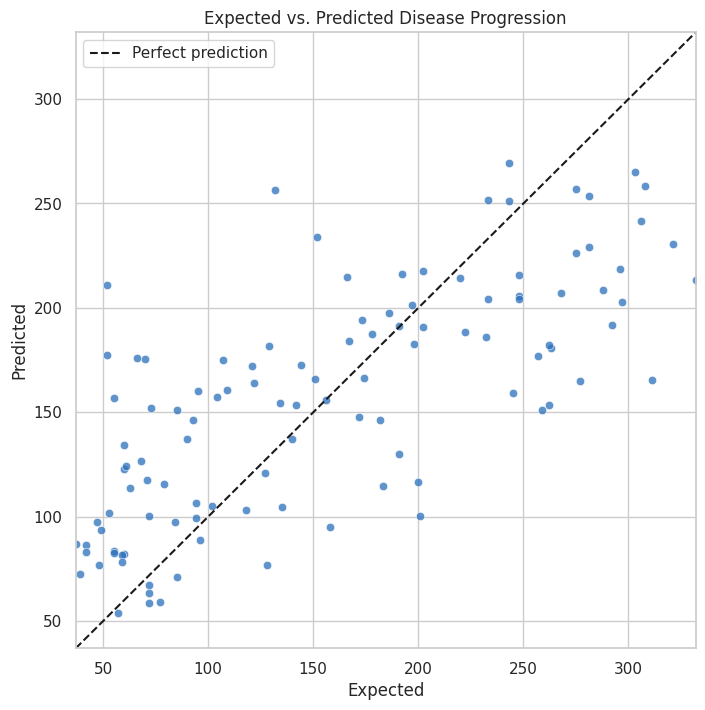

,Metric,Value
0,R-squared (R2),0.5322
1,Mean Absolute Error (MAE),47.1713
2,Root Mean Squared Error (RMSE),58.8067


In [6]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
predicted = linear_regression.predict(X_test)
expected = y_test.to_numpy()
comparison_df = pd.DataFrame({"Expected": expected, "Predicted": predicted, "Residual": expected - predicted})
display(comparison_df.head())

fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(data=comparison_df, x="Expected", y="Predicted", ax=ax, color="#2a6fbb", alpha=0.75)
start = min(comparison_df[["Expected", "Predicted"]].min())
end = max(comparison_df[["Expected", "Predicted"]].max())
ax.plot([start, end], [start, end], "k--", label="Perfect prediction")
ax.set_xlim(start, end)
ax.set_ylim(start, end)
ax.set_title("Expected vs. Predicted Disease Progression")
ax.legend()
plt.show()

metrics_summary = pd.DataFrame({
    "Metric": ["R-squared (R2)", "Mean Absolute Error (MAE)", "Root Mean Squared Error (RMSE)"],
    "Value": [r2_score(expected, predicted), mean_absolute_error(expected, predicted), mean_squared_error(expected, predicted) ** 0.5],
})
display(metrics_summary)

,Model,Mean CV R2,Std. Dev. CV R2
2,Lasso,0.4756,0.0763
0,LinearRegression,0.4747,0.0797
1,Ridge,0.4213,0.0744
3,ElasticNet,0.3609,0.0691


Best model by mean 10-fold CV R2: Lasso
Mean CV R2: 0.476


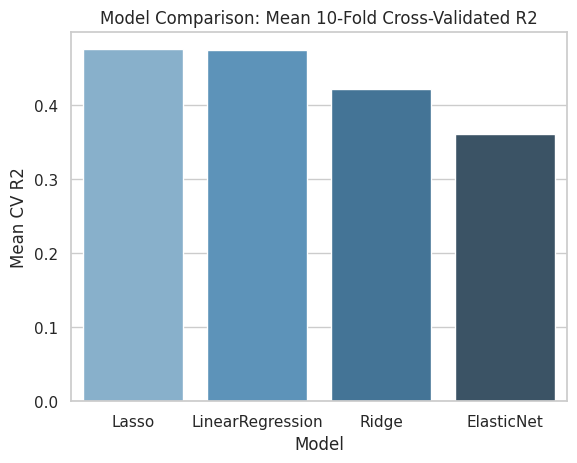

In [7]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import KFold, cross_val_score

estimators = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01, max_iter=10000),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000),
}
kfold = KFold(n_splits=10, random_state=11, shuffle=True)
results = []
for name, estimator in estimators.items():
    scores = cross_val_score(estimator, X, y, cv=kfold, scoring="r2")
    results.append({"Model": name, "Mean CV R2": scores.mean(), "Std. Dev. CV R2": scores.std()})
cv_results = pd.DataFrame(results).sort_values("Mean CV R2", ascending=False)
display(cv_results)

best_model = cv_results.iloc[0]
print(f"Best model by mean 10-fold CV R2: {best_model['Model']}")
print(f"Mean CV R2: {best_model['Mean CV R2']:.3f}")
sns.barplot(data=cv_results, x="Model", y="Mean CV R2", hue="Model", palette="Blues_d", legend=False)
plt.title("Model Comparison: Mean 10-Fold Cross-Validated R2")
plt.show()